# Inference: 30-Class Fruit Classifier (FIDS30)

Evaluate the trained model on the test set with confusion matrix and classification report.

In [13]:
import torch
import timm
from torchvision import datasets
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Setup Model
NUM_CLASSES = 30
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = timm.create_model('efficientnet_b0', pretrained=False, num_classes=NUM_CLASSES)
model.load_state_dict(torch.load("fids30_classifier_30cls_b0.pth", map_location=device))
model = model.to(device)
model.eval()

# 2. Setup Test Data
config = timm.data.resolve_model_data_config(model)
test_transform = timm.data.create_transform(**config, is_training=False)
test_ds = datasets.ImageFolder("PrepData/Test", transform=test_transform)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

print(f"Test samples: {len(test_ds)}")
print(f"Classes: {test_ds.classes}")

Test samples: 195
Classes: ['acerolas', 'apples', 'apricots', 'avocados', 'bananas', 'blackberries', 'blueberries', 'cantaloupes', 'cherries', 'coconuts', 'figs', 'grapefruits', 'grapes', 'guava', 'kiwifruit', 'lemons', 'limes', 'mangos', 'olives', 'oranges', 'passionfruit', 'peaches', 'pears', 'pineapples', 'plums', 'pomegranates', 'raspberries', 'strawberries', 'tomatoes', 'watermelons']


In [14]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. Classification Report
target_names = test_ds.classes
print("Test Set Performance:")
print(classification_report(all_labels, all_preds, target_names=target_names))

Test Set Performance:
              precision    recall  f1-score   support

    acerolas       0.60      0.60      0.60         5
      apples       0.53      1.00      0.70         8
    apricots       0.45      0.83      0.59         6
    avocados       1.00      0.80      0.89         5
     bananas       0.80      0.44      0.57         9
blackberries       0.78      0.88      0.82         8
 blueberries       1.00      0.67      0.80         6
 cantaloupes       0.86      1.00      0.92         6
    cherries       0.83      0.83      0.83         6
    coconuts       1.00      1.00      1.00         5
        figs       1.00      0.20      0.33         5
 grapefruits       1.00      0.83      0.91         6
      grapes       0.78      0.88      0.82         8
       guava       0.57      0.67      0.62         6
   kiwifruit       1.00      1.00      1.00         7
      lemons       0.25      0.17      0.20         6
       limes       0.86      1.00      0.92         6
     

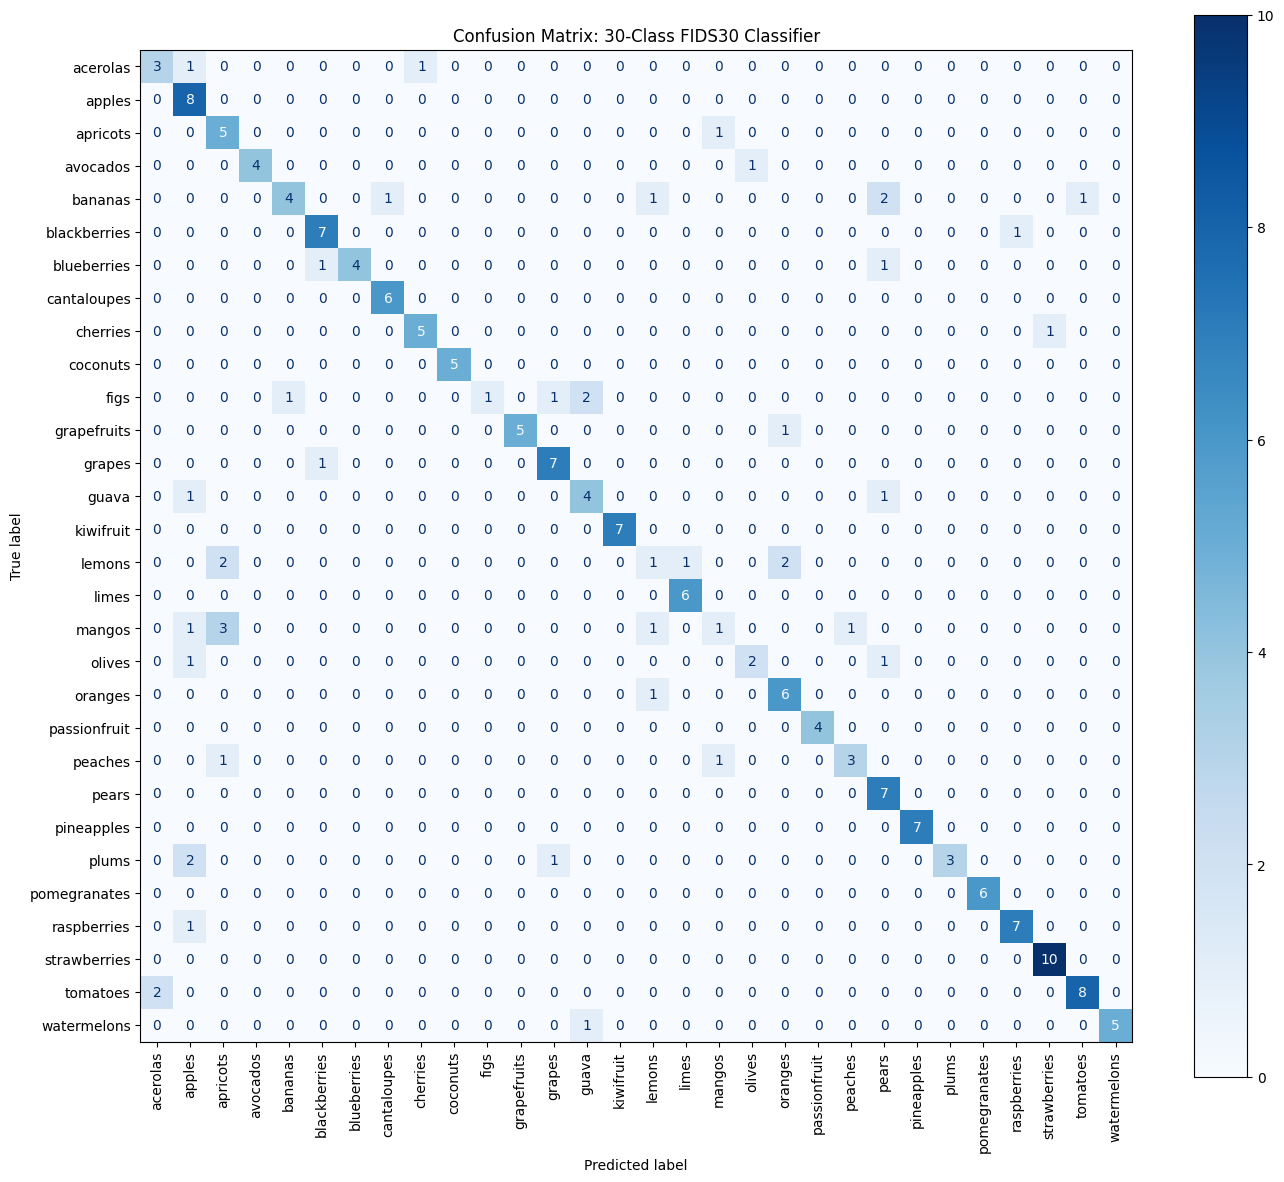

In [15]:
# 4. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=90)
plt.title("Confusion Matrix: 30-Class FIDS30 Classifier")
plt.tight_layout()
plt.show()